# Yolo 11
Here we train Yolo 11 nano segmentation, the same model used inside the baseline provided by the project.

In [1]:
from pathlib import Path
import pandas as pd
import time
import shutil

import cv2
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
from PIL import Image

### Configuration

In [2]:
def ensure_dir(path):
    Path(path).mkdir(
        parents=True,
        exist_ok=True,
    )


def resolve_device(device=None):
    if device is not None:
        return device

    return 0 if torch.cuda.is_available() else "cpu"


def get_image_files(directory):
    directory = Path(directory)

    image_paths = []

    for pattern in [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.bmp",
        "*.tif",
        "*.tiff",
    ]:
        image_paths.extend(
            directory.glob(pattern)
        )

    return sorted(image_paths)


def save_image(path, image):
    path = Path(path)

    ensure_dir(path.parent)

    if not cv2.imwrite(
        str(path),
        image,
    ):
        raise IOError(
            f"Unable to save image: {path}"
        )


def overlay_mask(
    image_bgr,
    mask,
    color=(0, 255, 255),
    alpha=0.45,
):
    colored = image_bgr.copy()
    colored[mask > 0] = color

    return cv2.addWeighted(
        colored,
        alpha,
        image_bgr,
        1.0 - alpha,
        0,
    )

In [3]:
PROJECT_ROOT = Path(
    "/home/federico-ai-rob/Scrivania/AIRO/MR_project"
).resolve()

cfg = {
    "device": None,

    "dataset_root": (
        PROJECT_ROOT
        / "yolo_dataset"
    ),

    "data_yaml": (
        PROJECT_ROOT
        / "configs"
        / "data_tools_yolo11.yaml"
    ),

    "base_weights": "yolo11n-seg.pt",

    "image_size": 640,
    "batch_size": 16,
    "epochs": 150,
    "patience": 100,

    "project": (
        PROJECT_ROOT
        / "outputs"
        / "yolo11"
    ),

    "run_name": "train_yolo11",
    "val_run_name": "val_yolo11",
    "inference_run_name": "inference_yolo11",
    "depth_run_name": "depth_yolo11",

    "confidence": 0.60,
}

YOLO_ROOT = Path(
    cfg["dataset_root"]
).resolve()

YOLO_DATA_YAML = Path(
    cfg["data_yaml"]
).resolve()

YOLO_OUTPUT_DIR = Path(
    cfg["project"]
).resolve()

TRAIN_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["run_name"]
)

VAL_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["val_run_name"]
)

INFERENCE_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["inference_run_name"]
)

DEPTH_OUTPUT_DIR = (
    YOLO_OUTPUT_DIR
    / cfg["depth_run_name"]
)

YOLO_DEVICE = resolve_device(
    cfg["device"]
)

ensure_dir(
    YOLO_DATA_YAML.parent
)

ensure_dir(
    YOLO_OUTPUT_DIR
)

ensure_dir(
    TRAIN_OUTPUT_DIR
)

ensure_dir(
    VAL_OUTPUT_DIR
)

ensure_dir(
    INFERENCE_OUTPUT_DIR
)

ensure_dir(
    DEPTH_OUTPUT_DIR
)

print("Project root:", PROJECT_ROOT)
print("Dataset:", YOLO_ROOT)
print("Data YAML:", YOLO_DATA_YAML)
print("YOLO output:", YOLO_OUTPUT_DIR)
print("Training output:", TRAIN_OUTPUT_DIR)
print("Validation output:", VAL_OUTPUT_DIR)
print("Inference output:", INFERENCE_OUTPUT_DIR)
print("Depth output:", DEPTH_OUTPUT_DIR)
print("Device:", YOLO_DEVICE)

Project root: /home/federico-ai-rob/Scrivania/AIRO/MR_project
Dataset: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset
Data YAML: /home/federico-ai-rob/Scrivania/AIRO/MR_project/configs/data_tools_yolo11.yaml
YOLO output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo11
Training output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo11/train_yolo11
Validation output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo11/val_yolo11
Inference output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo11/inference_yolo11
Depth output: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo11/depth_yolo11
Device: 0


### Yolo Dataset

In [4]:
class_names = [
    "tool0",
    "tool1",
    "tool2",
    "tool3",
    "tool4",
    "tool5",
    "tool6",
    "tool7",
    "tool8",
    "tool9",
    "tool10",
    "tool11",
    "tool12",
    "tool13",
    "tool14",
    "tool15",
    "tool16",
    "tool17",
    "tool18",
    "tool19",
    "tool20",
]
data_config = {
    "path": str(
        YOLO_ROOT.resolve()
    ),

    "train": str(
        (
            YOLO_ROOT
            / "images"
            / "train"
        ).resolve()
    ),

    "val": str(
        (
            YOLO_ROOT
            / "images"
            / "val"
        ).resolve()
    ),

    "test": str(
        (
            YOLO_ROOT
            / "images"
            / "test"
        ).resolve()
    ),

    "names": class_names,
}

with open(
    YOLO_DATA_YAML,
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        data_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print(
    "YAML file created:",
    YOLO_DATA_YAML.resolve(),
)

with open(
    YOLO_DATA_YAML,
    "r",
    encoding="utf-8",
) as file:
    print(file.read())


YAML file created: /home/federico-ai-rob/Scrivania/AIRO/MR_project/configs/data_tools_yolo11.yaml
path: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset
train: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/images/train
val: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/images/val
test: /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/images/test
names:
- tool0
- tool1
- tool2
- tool3
- tool4
- tool5
- tool6
- tool7
- tool8
- tool9
- tool10
- tool11
- tool12
- tool13
- tool14
- tool15
- tool16
- tool17
- tool18
- tool19
- tool20



In [5]:
for split in ["train", "val", "test"]:
    image_dir = YOLO_ROOT / "images" / split
    label_dir = YOLO_ROOT / "labels" / split

    image_count = len(
        get_image_files(image_dir)
    )

    label_count = len(
        list(label_dir.glob("*.txt"))
    )

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{label_count} labels"
    )

train: 2880 images, 2880 labels
val: 760 images, 760 labels
test: 182 images, 182 labels


### Yolo stage

In [6]:
def predict_instances(
    model,
    image_bgr,
    confidence,
    device,
):
    """
    Runs YOLO11-seg on a single image and returns
    a list of predicted instances.

    Each instance contains:
    - a binary mask at the original resolution;
    - class_id;
    - confidence.
    """
    results = model.predict(
        source=image_bgr,
        conf=confidence,
        device=device,
        verbose=False,
    )

    result = results[0]
    height, width = image_bgr.shape[:2]

    if (
        result.masks is None
        or result.boxes is None
    ):
        return []

    masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    class_ids = (
        result.boxes.cls
        .detach()
        .cpu()
        .numpy()
        .astype(np.int64)
    )

    confidences = (
        result.boxes.conf
        .detach()
        .cpu()
        .numpy()
    )

    instances = []

    for mask, class_id, conf in zip(
        masks,
        class_ids,
        confidences,
    ):
        binary_mask = (
            mask > 0.5
        ).astype(np.uint8)

        binary_mask = cv2.resize(
            binary_mask,
            (width, height),
            interpolation=cv2.INTER_NEAREST,
        )

        instances.append({
            "mask": binary_mask,
            "class_id": int(class_id),
            "confidence": float(conf),
        })

    return instances


def merge_tool_masks(
    instances,
    image_shape,
):
    """
    Aggregates the masks of all instances/classes.

    Output:
    - 0: background;
    - 255: pixel belonging to a tool.
    """
    height, width = image_shape[:2]

    tool_mask = np.zeros(
        (height, width),
        dtype=np.uint8,
    )

    for instance in instances:
        tool_mask[
            instance["mask"] > 0
        ] = 255

    return tool_mask

### Model Training

In [7]:
model = YOLO(
    cfg["base_weights"]
)

start_time = time.time()

train_results = model.train(
    data=str(YOLO_DATA_YAML),
    task="segment",

    epochs=cfg["epochs"],
    imgsz=cfg["image_size"],
    batch=cfg["batch_size"],
    patience=cfg["patience"],

    device=YOLO_DEVICE,

    project=str(YOLO_OUTPUT_DIR),
    name=cfg["run_name"],
    exist_ok=True,
)

elapsed_minutes = (
    time.time() - start_time
) / 60.0

print(
    f"Training completed in "
    f"{elapsed_minutes:.2f} minutes."
)

New https://pypi.org/project/ultralytics/8.4.138 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.136 🚀 Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/federico-ai-rob/Scrivania/AIRO/MR_project/configs/data_tools_yolo11.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=N

### Verification Inference

In [8]:
best_weights = (
    YOLO_OUTPUT_DIR
    / cfg["run_name"]
    / "weights"
    / "best.pt"
)

if not best_weights.exists():
    raise FileNotFoundError(
        "best.pt not found: "
        f"{best_weights.resolve()}"
    )

best_model = YOLO(
    str(best_weights)
)

print(
    "Best checkpoint loaded:",
    best_weights.resolve()
)

Best checkpoint loaded: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo11/train_yolo11/weights/best.pt


In [9]:
validation_results = best_model.val(
    data=str(YOLO_DATA_YAML),
    split="val",
    device=YOLO_DEVICE,

    project=str(YOLO_OUTPUT_DIR),
    name=cfg["val_run_name"],
    exist_ok=True,
)
print(
    "Validation completed."
)

Ultralytics 8.4.136 🚀 Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
YOLO11n-seg summary (fused): 114 layers, 2,838,663 parameters, 0 gradients, 9.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6284.8±1050.1 MB/s, size: 660.1 KB)
val: Scanning /home/federico-ai-rob/Scrivania/AIRO/MR_project/yolo_dataset/labels/val.cache... 760 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 760/760 398.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 10.3it/s 4.7s0.1s
                   all        760       2041      0.663      0.506      0.488      0.388      0.649      0.489      0.459      0.301
                 tool0         15         18          0          0    0.00495    0.00458          0          0    0.00495    0.00424
                 tool1        139        139      0.819      0.912      0.876      0.762      0.819   

In [10]:
test_images_dir = (
    YOLO_ROOT
    / "images"
    / "test"
)

test_image_paths = get_image_files(
    test_images_dir
)

if not test_image_paths:
    raise RuntimeError(
        "No images found in the test set."
    )

sample_path = test_image_paths[0]

image_bgr = cv2.imread(
    str(sample_path)
)

if image_bgr is None:
    raise RuntimeError(
        f"Image not readable: "
        f"{sample_path}"
    )

instances = predict_instances(
    model=best_model,
    image_bgr=image_bgr,
    confidence=cfg["confidence"],
    device=YOLO_DEVICE,
)

tool_mask = merge_tool_masks(
    instances=instances,
    image_shape=image_bgr.shape,
)

overlay = overlay_mask(
    image_bgr=image_bgr,
    mask=tool_mask,
)

print(
    "Number of predicted instances:",
    len(instances),
)

print(
    "Predicted classes:",
    [
        item["class_id"]
        for item in instances
    ],
)

print(
    "Confidence scores:",
    [
        round(
            item["confidence"],
            3,
        )
        for item in instances
    ],
)

Number of predicted instances: 1
Predicted classes: [1]
Confidence scores: [0.816]


In [11]:
inference_dir = INFERENCE_OUTPUT_DIR

ensure_dir(
    inference_dir
)

save_image(
    inference_dir / "input.png",
    image_bgr,
)

save_image(
    inference_dir / "tool_mask.png",
    tool_mask,
)

save_image(
    inference_dir / "overlay.png",
    overlay,
)

print(
    "Output salvati in:",
    inference_dir.resolve(),
)

Output salvati in: /home/federico-ai-rob/Scrivania/AIRO/MR_project/outputs/yolo11/inference_yolo11


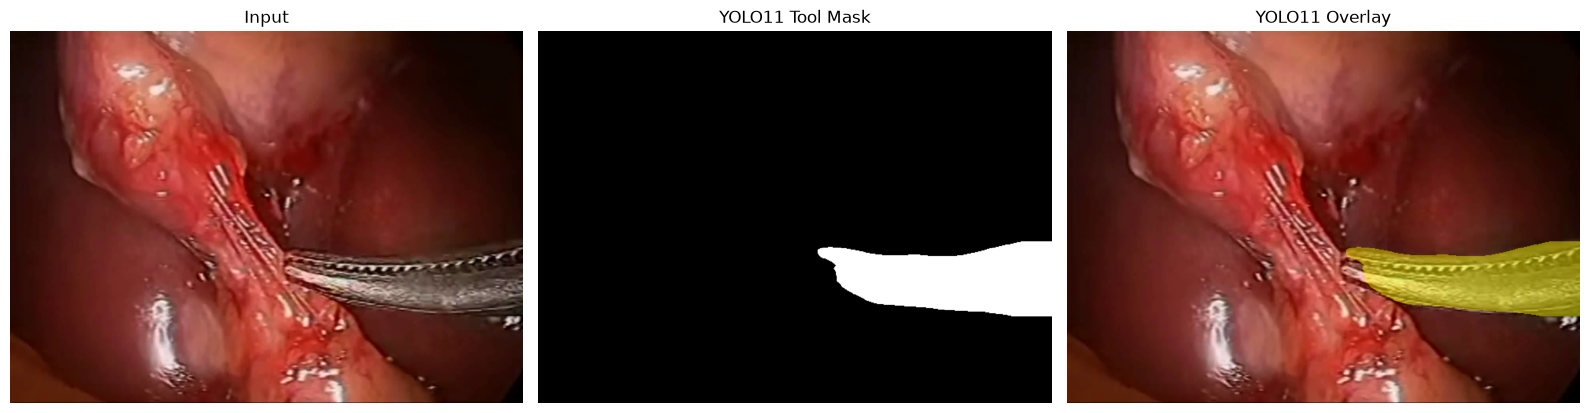

In [12]:
image_rgb = cv2.cvtColor(
    image_bgr,
    cv2.COLOR_BGR2RGB,
)

overlay_rgb = cv2.cvtColor(
    overlay,
    cv2.COLOR_BGR2RGB,
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    tool_mask,
    cmap="gray",
)
plt.title("YOLO11 Tool Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_rgb)
plt.title("YOLO11 Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
### Cleanup Temporary Ultralytics Directory

RUNS_DIR = (
    PROJECT_ROOT
    / "runs"
)

if RUNS_DIR.exists():
    shutil.rmtree(
        RUNS_DIR
    )

    print(
        "Temporary runs directory removed:",
        RUNS_DIR,
    )
else:
    print(
        "No temporary runs directory found."
    )

Temporary runs directory removed: /home/federico-ai-rob/Scrivania/AIRO/MR_project/runs
